# Verifying IFS solar forecasts against SURFRAD at Bondville, IL

This notebook ([#109](https://github.com/williamhobbs/hefty/issues/109)) verifies hefty's IFS forecasts from [dynamical.org](https://dynamical.org) against ground measurements. It covers every hourly lead from 1 to 72 hours for each daily 00Z initialization in August 2026.

- **Ground truth**: the NOAA [SURFRAD](https://gml.noaa.gov/grad/surfrad/) station at [Bondville, IL](https://gml.noaa.gov/grad/surfrad/bondvill.html) (`bon`), fetched with `pvlib.iotools.get_surfrad`. It provides 1-minute measured GHI, DNI, DHI, air temperature and wind speed.
- **PV plant**: [Solar Farm 2.0](https://fs.illinois.edu/Projects/solar-farm-2-0/) at the University of Illinois Urbana-Champaign, about 12 km east of the station. It has 12.3 MWdc / 10 MWac of bifacial modules on north-south single-axis trackers. The plant's power output is not public, so "observed" power is modelled with `hefty.pv_model.model_pv_power` from the SURFRAD measurements, using the plant's specifications.
- **Forecast**: `hefty.solar.get_solar_forecast(model='ifs', priority='dynamical')`.
- **Baseline**: ERA5 reanalysis from [`pvlib.iotools.get_era5`](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_era5.html), scored against SURFRAD in the same way. Reanalysis isn't a forecast, but it shows how close a model can get to the station when it has seen the actual weather. This puts the forecast errors in context.
- **Verification**: [xskillscore](https://xskillscore.readthedocs.io) and [climpred](https://climpred.readthedocs.io).

### Credentials
ERA5 needs a CDS personal access token in a `.env` file at the repository root. `.env` is already listed in `.gitignore`. SURFRAD and dynamical don't need credentials.
```
PRIVATE_CDSAPI_KEY=<your CDS personal access token>
```
You need to accept the ERA5 licence on the CDS website once before the key will work.

### Extra dependencies
hefty does not depend on these packages. Install them, then restart the kernel. pvlib needs nothing extra, because `get_surfrad` and `get_era5` ship with it.

**dynamical.org** (IFS forecast via hefty) and `python-dotenv` (to read `.env`):

In [ ]:
%pip install -q dynamical_catalog cartopy python-dotenv

**Forecast verification**:

In [ ]:
%pip install -q climpred xskillscore

In [3]:
import os
import warnings
from pathlib import Path

import climpred
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import xarray as xr
import xskillscore as xs
from dotenv import find_dotenv, load_dotenv

from hefty.pv_model import model_pv_power
from hefty.solar import get_solar_forecast

warnings.simplefilter(action='ignore', category=FutureWarning)
load_dotenv(find_dotenv(usecwd=True));

## Site, plant and period
Forecasts and ERA5 are taken at the SURFRAD station's coordinates, because that is where the ground truth is measured. The PV model uses Solar Farm 2.0's published specifications. Its ground coverage ratio is not published, so a typical 0.35 is assumed. hefty's bifacial model only supports the Hay-Davies and isotropic transposition models, so Hay-Davies is used.

Each forecast is initialized at 00Z, which is 7 pm local time (CDT) the evening before. Every hourly lead from 1 to 72 hours is kept and grouped into 24-hour **lead days** 0, 1 and 2. Each lead day contains one full daylight period: sunrise is around 11 UTC and sunset around 01 UTC in August.

In [4]:
station = 'bon'
latitude, longitude = 40.05192, -88.37309  # SURFRAD Bondville, IL

plant = dict(  # UIUC Solar Farm 2.0
    latitude=latitude,
    longitude=longitude,
    mount_type='single-axis',
    gcr=0.35,                 # assumed
    nameplate_dc=12.32,       # MW
    nameplate_ac=10,          # MW
    dc_loss_fraction=0.1,
    gamma_pdc=-0.0035,
    shade_loss_model='non-linear_simple',
    backtrack=True,
    max_tracker_angle=60,
    bifacial=True,
    bifaciality_factor=0.7,
    default_site_transposition_model='haydavies',
)
albedo = 0.2

init_dates = pd.date_range('2026-08-01', '2026-08-31', freq='1D')  # 00Z initializations
lead_time_to_start, run_length = 0, 72                             # hours
period_start = init_dates[0]
period_end = init_dates[-1] + pd.Timedelta(hours=lead_time_to_start + run_length)
hours = pd.date_range(period_start + pd.Timedelta('1h'), period_end, freq='1h', tz='UTC')  # hour-ending

## SURFRAD observations
`get_surfrad` returns 1-minute data in UTC, with values that fail quality control already set to NaN. Night-time irradiance can be slightly negative because of sensor offsets, so it is clipped at 0. The 1-minute values are then averaged into hours, using hour-ending timestamps like ERA5. Any hour with fewer than 50 valid minutes is set to NaN.

In [5]:
surfrad, surfrad_meta = pvlib.iotools.get_surfrad(station, period_start, period_end)
irradiance = ['ghi', 'dni', 'dhi']
minute = surfrad[irradiance + ['temp_air', 'wind_speed']].copy()
minute[irradiance] = minute[irradiance].clip(lower=0)

hourly = minute.resample('1h', closed='right', label='right')
surfrad_1h = hourly.mean().where(hourly.count()['ghi'] >= 50, axis=0).reindex(hours)
print(surfrad_meta['name'], surfrad_meta['latitude'], surfrad_meta['longitude'],
      f"| {surfrad_1h['ghi'].isna().sum()} of {len(surfrad_1h)} hours missing")
surfrad_1h.describe().round(1)

Bondville 40.05 -88.37 | 12 of 792 hours missing


,ghi,dni,dhi,temp_air,wind_speed
count,780.0,771.0,780.0,780.0,780.0
mean,231.2,196.1,101.8,23.2,2.9
std,295.7,281.5,128.2,3.9,1.5
min,0.0,0.0,0.0,13.0,0.2
25%,0.0,0.0,0.1,20.4,1.9
50%,36.5,1.3,34.2,23.1,2.6
75%,452.1,387.4,173.0,25.8,3.7
max,1001.7,906.3,550.4,34.6,8.6


## ERA5 baseline from pvlib
The CDS time-series API only accepts long variable names. `map_variables=True` renames the output to pvlib's names and units. ERA5 radiation is accumulated over the hour ending at the timestamp, so the index already uses the same hour-ending convention as `surfrad_1h`.

In [6]:
era5, era5_meta = pvlib.iotools.get_era5(
    latitude, longitude, period_start, period_end,
    variables=['surface_solar_radiation_downwards', '2m_temperature',
               '10m_u_component_of_wind', '10m_v_component_of_wind'],
    api_key=os.environ['PRIVATE_CDSAPI_KEY'], timeout=600)
era5['wind_speed'] = np.hypot(era5.pop('u10'), era5.pop('v10'))
era5 = era5.reindex(hours)
print(era5_meta['latitude'], era5_meta['longitude'])
era5.head()

40.0 -88.25


,temp_air,ghi,wind_speed
2026-08-01 01:00:00+00:00,23.07803,33.706667,5.932419
2026-08-01 02:00:00+00:00,22.14620,0.035556,6.038274
2026-08-01 03:00:00+00:00,21.79568,0.000000,6.163264
2026-08-01 04:00:00+00:00,21.62557,0.000000,6.262629
2026-08-01 05:00:00+00:00,21.32650,0.000000,6.088751


## IFS forecasts from dynamical.org
See [dynamical_example.ipynb](dynamical_example.ipynb) for more on dynamical. Each call takes about 30–45 s, so 31 initializations take about 20 minutes the first time. Every forecast is then cached as a CSV under `~/data/hefty_era5_example/`, which makes reruns instant.

In [7]:
cache_dir = Path.home() / 'data' / 'hefty_era5_example'
cache_dir.mkdir(parents=True, exist_ok=True)

def get_ifs_cached(init_date):
    path = cache_dir / (f'ifs_dynamical_{init_date:%Y%m%d%H}_{lead_time_to_start}-{run_length}h'
                        f'_{latitude}_{longitude}.csv')
    if path.exists():
        return pd.read_csv(path, index_col=0, parse_dates=True)
    df = get_solar_forecast(
        latitude=latitude, longitude=longitude, init_date=init_date,
        run_length=run_length, lead_time_to_start=lead_time_to_start,
        model='ifs', attempts=3, priority='dynamical')
    df.to_csv(path)
    return df

fcasts = {init: get_ifs_cached(init) for init in init_dates}
fcasts[init_dates[0]].head()

,point,temp_air,wind_speed,wind_direction,lead_time,ghi_csi,ghi,dni,dhi,ghi_clear
valid_time,,,,,,,,,,
2026-08-01 00:30:00+00:00,0,22.4375,5.509118,151.63893,0.5,0.645764,49.635088,0.0,49.635088,76.862609
2026-08-01 01:30:00+00:00,0,22.0625,5.347538,156.07523,1.5,0.645764,0.000000,0.0,0.000000,0.000000
2026-08-01 02:30:00+00:00,0,21.6875,5.185958,160.51152,2.5,0.645764,0.000000,0.0,0.000000,0.000000
2026-08-01 03:30:00+00:00,0,21.4375,5.058215,160.40500,3.5,0.000000,0.000000,0.0,0.000000,NaN
2026-08-01 04:30:00+00:00,0,21.3125,4.964307,155.75565,4.5,0.000000,0.000000,0.0,0.000000,NaN


## PV power and xarray datasets
`model_pv_power` expects timestamps at the centre of each interval, as hefty forecasts have. SURFRAD and ERA5 are therefore shifted back 30 minutes before modelling, and every result is then moved back to the hour-ending convention.

- **SURFRAD**: uses the measured GHI, DNI and DHI directly.
- **ERA5**: provides only GHI, so DNI and DHI are estimated with the Erbs decomposition, which is also hefty's default for forecasts.

Lead `L` of a forecast initialized at `init` is then valid at `init + L` hours. The data is arranged the way climpred expects:

- `fc`: IFS forecasts with `init` and `lead` dimensions
- `obs`: SURFRAD with a `time` dimension
- `era5_ds`: ERA5 with a `time` dimension, used as climpred's `uninitialized` reference

In [8]:
half_hour = pd.Timedelta('30min')

def to_interval_centre(df):
    return df.set_axis(df.index - half_hour)

def to_interval_end(df):
    return df.set_axis((df.index + half_hour).tz_convert(None))

def add_decomposition(df):
    df = df.copy()
    sp = pvlib.solarposition.get_solarposition(df.index, latitude, longitude)
    erbs = pvlib.irradiance.erbs(df['ghi'], sp['zenith'], df.index)
    df['dni'], df['dhi'] = erbs['dni'], erbs['dhi']
    return df

def pv_power(resource):
    resource = resource.copy()
    resource['albedo'] = albedo
    return model_pv_power(resource_data=resource, **plant)[0]

def ghi_and_power(resource):
    """Interval-centred resource -> hour-ending GHI and PV power."""
    return to_interval_end(pd.DataFrame({'ghi': resource['ghi'], 'power': pv_power(resource)}))

# observations and baseline: time
obs_df = ghi_and_power(to_interval_centre(surfrad_1h))
era5_df = ghi_and_power(add_decomposition(to_interval_centre(era5)))
obs = obs_df.rename_axis('time').to_xarray()
era5_ds = era5_df.rename_axis('time').to_xarray()

# IFS forecasts: init x lead
rows = []
for init, f in fcasts.items():
    f = to_interval_end(f.assign(power=pv_power(f)))
    f['init'] = init
    f['lead'] = ((f.index - init) / pd.Timedelta('1h')).astype(int)
    rows.append(f.rename_axis('valid_time').reset_index())
fc_long = pd.concat(rows, ignore_index=True)
fc_long['lead_day'] = (fc_long['lead'] - 1) // 24

fc = fc_long.set_index(['init', 'lead'])[['ghi', 'power']].to_xarray()
fc.lead.attrs['units'] = 'hours'
fc

<xarray.Dataset> Size: 37kB
Dimensions:  (init: 31, lead: 72)
Coordinates:
  * init     (init) datetime64[us] 248B 2026-08-01 2026-08-02 ... 2026-08-31
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (init, lead) float64 18kB 49.64 0.0 0.0 0.0 ... 433.4 271.3 105.0
    power    (init, lead) float64 18kB 0.5414 0.0 0.0 0.0 ... 7.317 6.597 2.438

### SURFRAD and ERA5 on the same `init` × `lead` grid
For each initialization and lead, this cell picks the SURFRAD and ERA5 values at the valid time `init + lead`. The results, `verif` and `era5_grid`, have the same shape as `fc`, so xskillscore can compare them directly.

In [9]:
valid_time = fc.init + fc.lead * np.timedelta64(1, 'h')
verif = obs.sel(time=valid_time).drop_vars('time')
era5_grid = era5_ds.sel(time=valid_time).drop_vars('time')
verif

<xarray.Dataset> Size: 37kB
Dimensions:  (init: 31, lead: 72)
Coordinates:
  * init     (init) datetime64[us] 248B 2026-08-01 2026-08-02 ... 2026-08-31
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (init, lead) float64 18kB 19.59 0.445 0.0 0.0 ... 461.3 252.2 79.0
    power    (init, lead) float64 18kB 0.1984 0.0 0.0 0.0 ... 8.249 6.053 1.503

### Time series: SURFRAD vs ERA5 and each IFS lead day
This shows the first 10 days of August, so the individual days are easier to see.

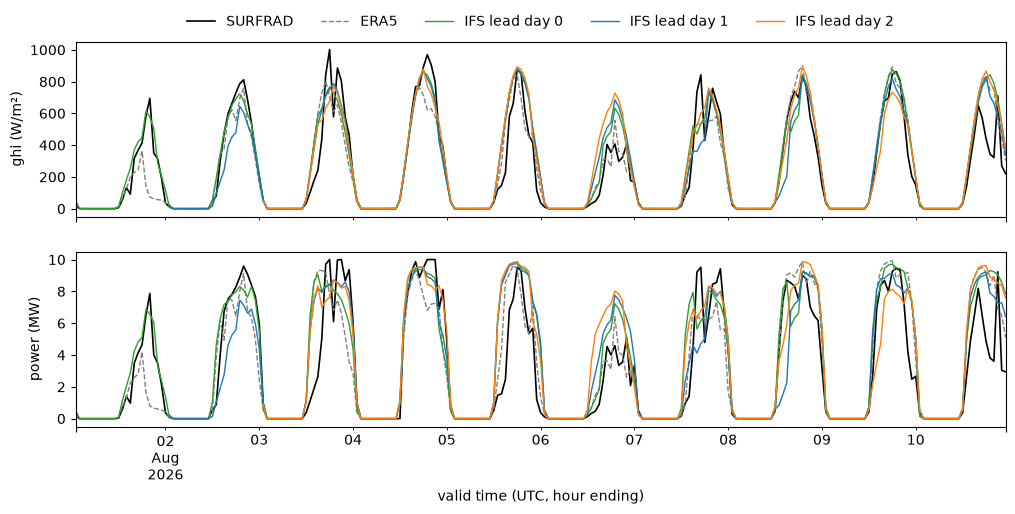

In [10]:
window = slice('2026-08-01', '2026-08-10')
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, var, unit in zip(axes, ['ghi', 'power'], ['W/m²', 'MW']):
    obs_df[var][window].plot(ax=ax, color='black', lw=1.2, label='SURFRAD')
    era5_df[var][window].plot(ax=ax, color='grey', lw=1, ls='--', label='ERA5')
    for day, color in [(0, 'tab:green'), (1, 'tab:blue'), (2, 'tab:orange')]:
        s = fc_long[fc_long['lead_day'] == day].set_index('valid_time')[var][window]
        s.plot(ax=ax, color=color, lw=1, label=f'IFS lead day {day}')
    ax.set_ylabel(f'{var} ({unit})')
axes[0].legend(ncol=5, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
axes[1].set_xlabel('valid time (UTC, hour ending)')
plt.show()

## Verification
### RMSE by lead with xskillscore
For IFS and for ERA5, the RMSE against SURFRAD is computed over all 31 initializations, giving one value per lead hour. `skipna=True` skips hours with missing SURFRAD data.

In [11]:
rmse_xs = xr.concat(
    [xs.rmse(fc, verif, dim='init', skipna=True),
     xs.rmse(era5_grid, verif, dim='init', skipna=True)],
    dim=pd.Index(['IFS', 'ERA5'], name='source'))
rmse_xs

<xarray.Dataset> Size: 3kB
Dimensions:  (source: 2, lead: 72)
Coordinates:
  * source   (source) StringDType(na_object=nan) 32B 'IFS' 'ERA5'
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (source, lead) float64 1kB 11.8 0.1891 0.06017 ... 83.26 39.18
    power    (source, lead) float64 1kB 0.179 0.0 0.0 0.0 ... 2.805 2.627 1.588

### RMSE by lead with climpred `verify`
`HindcastEnsemble.verify` lines each forecast up with the observation at its valid time. ERA5 is added as the `uninitialized` dataset, so `reference='uninitialized'` scores it alongside IFS. The result is the same as the xskillscore calculation above. With `alignment='same_inits'`, every lead hour is scored on the same initializations.

In [12]:
hindcast = (climpred.HindcastEnsemble(fc)
            .add_observations(obs)
            .add_uninitialized(era5_ds))

def verify(metric):
    skill = hindcast.verify(metric=metric, comparison='e2o', dim='init', alignment='same_inits',
                            reference='uninitialized', skipna=True)
    return (skill.assign_coords(skill=['IFS', 'ERA5'])
            .rename(skill='source')
            .transpose('source', 'lead'))

rmse = verify('rmse')
xr.testing.assert_allclose(rmse, rmse_xs)  # identical to xskillscore
rmse

<xarray.Dataset> Size: 3kB
Dimensions:  (source: 2, lead: 72)
Coordinates:
  * source   (source) <U4 32B 'IFS' 'ERA5'
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (source, lead) float64 1kB 11.8 0.1891 0.06017 ... 83.26 39.18
    power    (source, lead) float64 1kB 0.179 0.0 0.0 0.0 ... 2.805 2.627 1.588
Attributes:
    prediction_skill_software:     climpred https://climpred.readthedocs.io/
    skill_calculated_by_function:  HindcastEnsemble.verify()
    number_of_initializations:     31
    alignment:                     same_inits
    metric:                        rmse
    comparison:                    e2o
    dim:                           init
    reference:                     ['uninitialized']
    skipna:                        True

### Plots by lead
For each lead hour, these plots show the mean bias (forecast minus SURFRAD, `metric='me'`) and the RMSE, averaged over all initializations. Only daytime leads are shown, defined as lead hours where the mean SURFRAD GHI is above 5 W/m².

In [13]:
daytime = verif['ghi'].mean('init') > 5  # W/m²
styles = {'IFS': dict(marker='.', lw=1.5), 'ERA5': dict(color='grey', ls='--', lw=1)}

def plot_vs_lead(ds, name, ylim_bottom=None):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    for ax, var, unit in zip(axes, ['ghi', 'power'], ['W/m²', 'MW']):
        for source, style in styles.items():
            ds[var].sel(source=source).where(daytime).plot(ax=ax, label=source, **style)
        for day in (0, 1, 2):
            ax.text(24 * day + 2, 0.88, f'lead day {day}', transform=ax.get_xaxis_transform())
        ax.axvspan(24.5, 48.5, color='grey', alpha=0.1)
        if ylim_bottom is None:
            ax.axhline(0, color='black', lw=0.8)
        else:
            ax.set_ylim(bottom=ylim_bottom)
        ax.set_title('')
        ax.set_xlabel('')
        ax.set_ylabel(f'{name} {var} ({unit})')
    axes[0].legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
    axes[1].set_xlim(0.5, 72.5)
    axes[1].set_xlabel('lead (hours, hour ending)')
    plt.show()

### Bias vs lead

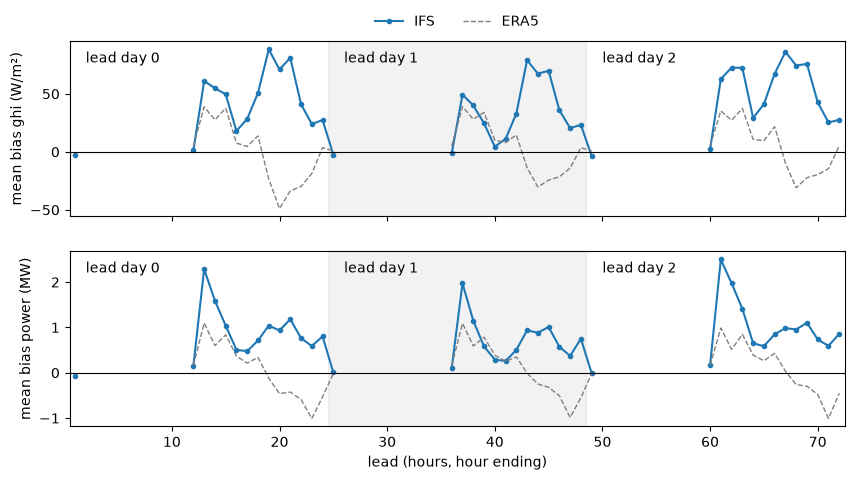

In [14]:
bias = verify('me')
plot_vs_lead(bias, 'mean bias')

### Skill vs lead

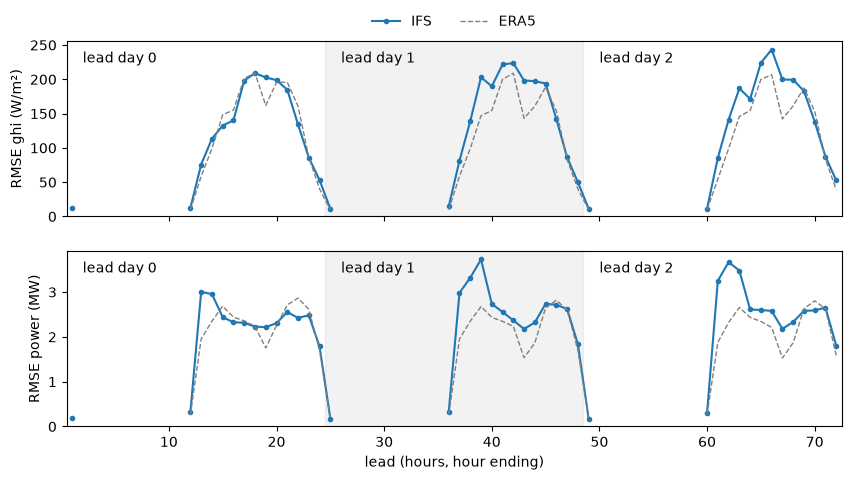

In [15]:
plot_vs_lead(rmse, 'RMSE', ylim_bottom=0)

### Daily energy
Daily energy is what a day-ahead market cares about most. This cell sums PV power over each lead day, giving one value per initialization and lead day, then scores IFS and ERA5 against SURFRAD. Lead days that contain a SURFRAD gap are dropped.

In [16]:
lead_day = ((fc.lead - 1) // 24).rename('lead_day')

def daily_energy(ds):  # MWh per lead day, NaN if any hour is missing
    return ds['power'].groupby(lead_day).sum(skipna=False)

obs_energy = daily_energy(verif)
rows = {}
for source, ds in [('IFS', fc), ('ERA5', era5_grid)]:
    energy = daily_energy(ds)
    kw = dict(dim='init', skipna=True)
    rows[source] = pd.DataFrame({
        'mean bias (MWh/day)': xs.me(energy, obs_energy, **kw).to_series(),
        'MAE (MWh/day)': xs.mae(energy, obs_energy, **kw).to_series(),
        'MAPE (%)': 100 * xs.mape(energy, obs_energy, **kw).to_series(),
    })
energy_scores = pd.concat(rows, axis=1)
energy_scores.insert(0, ('SURFRAD', 'mean (MWh/day)'), obs_energy.mean('init', skipna=True).to_series())
energy_scores.round(1)

SURFRAD                 IFS                         \
         mean (MWh/day) mean bias (MWh/day) MAE (MWh/day) MAPE (%)   
lead_day                                                             
0                  72.0                12.0          13.7     17.3   
1                  73.7                 9.4          16.7     20.8   
2                  73.8                13.4          16.0     18.8   

                        ERA5                         
         mean bias (MWh/day) MAE (MWh/day) MAPE (%)  
lead_day                                             
0                        0.5          11.7     18.7  
1                        1.0          11.2     15.3  
2                        1.1          11.0     15.1

-----
_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF). © 2026 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution 4.0 International (CC BY 4.0). https://creativecommons.org/licenses/by/4.0/_

_ECMWF Data have been modified using the functions included in the hefty Python package (e.g., interpolation to hourly values)._

_Contains modified Copernicus Climate Change Service information 2026 (ERA5, Hersbach et al., 2023, doi:10.24381/cds.adbb2d47). Neither the European Commission nor ECMWF is responsible for any use that may be made of the Copernicus information or data it contains._

_SURFRAD data courtesy of NOAA Global Monitoring Laboratory._